# Part 1: Data Ingestion
## Programmatic Download (5 marks)

In [1]:
pip install pyspark pandas matplotlib numpy spark 

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pypdf langchain langchain-community chromadb openai sentence-transformers  

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install openai tiktoken  

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Paste your API key from Satori
# (https://satori.sergiomathurin.com/courses/comp3610/synapse)
LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = "<removed>"

In [5]:
import os
import sys

os.environ['HADOOP_HOME'] = r'C:\hadoop'
os.environ['PATH'] = r'C:\hadoop\bin;' + os.environ.get('PATH', '')

# Verify it's set correctly
print(f"HADOOP_HOME: {os.environ['HADOOP_HOME']}")
print(f"winutils exists: {os.path.exists(r'C:\hadoop\bin\winutils.exe')}")

HADOOP_HOME: C:\hadoop
winutils exists: True


In [6]:
import os
import sys
import requests
import pandas as pd
import polars as pl
import duckdb
from datetime import datetime
import time
from pathlib import Path
import requests

import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [7]:
data_dir = Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

trip_data_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
trip_data_file = data_dir / "yellow_tripdata_2024-01.parquet"

zone_data_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zone_data_file = data_dir / "taxi_zone_lookup.csv"

In [8]:
def download_file(url, file_path):
    if not file_path.exists():
        print(f"Downloading from: {url}")
        response = requests.get(url)
        
        with open(file_path, 'wb') as f:
            f.write(response.content)
        
        file_size_mb = os.path.getsize(file_path) / 1e6
        print(f"Downloaded: {file_path.name} ({file_size_mb:.1f} MB)")
        return True
    else:
        file_size_mb = os.path.getsize(file_path) / 1e6
        print(f"File already exists: {file_path.name} ({file_size_mb:.1f} MB)")
        return False

In [9]:
download_file(trip_data_url, trip_data_file)

download_file(zone_data_url, zone_data_file)


File already exists: yellow_tripdata_2024-01.parquet (50.0 MB)
File already exists: taxi_zone_lookup.csv (0.0 MB)


False

# Assignment 3

# Part 1: Distributed Data Processing with Spark (30 marks)

## Task 1.1: Spark Environment Setup & Data Loading (5 marks) 

In [10]:
from pyspark.sql import SparkSession 
 
spark = SparkSession.builder.master('local[*]') .appName('COMP3610_A3') .config('spark.sql.adaptive.enabled', 'true') .config('spark.driver.memory', '4g') .getOrCreate() 
 
# Verify the session 
print(f'Spark version: {spark.version}') 
print(f'App name: {spark.sparkContext.appName}') 
print(f'Master: {spark.sparkContext.master}') 
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}') 

Spark version: 4.1.1
App name: COMP3610_A3
Master: local[*]
Default parallelism: 8


In [11]:
df = spark.read.parquet('data/raw/yellow_tripdata_2024-01.parquet') 
 
df.printSchema() 
 
# Basic statistics 
print(f'Number of rows: {df.count():,}') 
print(f'Number of columns: {len(df.columns)}') 
print(f'Number of partitions: {df.rdd.getNumPartitions()}')

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

Number of rows: 2,964,624
Number of columns: 19
Number of partitions: 8


In [12]:
# Load TIme Spark 
# Time Spark read 
start = time.time() 
df_spark = spark.read.parquet('data/raw/yellow_tripdata_2024-01.parquet') 
spark_read_time = time.time() - start 
 
# Time Spark action 
start = time.time() 
spark_count = df_spark.count()

In [13]:
spark_action_time = time.time() - start 
 
# Time Pandas read 
start = time.time() 
df_pandas = pd.read_parquet(trip_data_file) 
pandas_read_time = time.time() - start 
 
print(f'Spark schema read:    {spark_read_time:.3f}s (lazy - no data loaded)') 
print(f'Spark count action:   {spark_action_time:.3f}s ({spark_count:,} rows)') 
print(f'Pandas full read:     {pandas_read_time:.3f}s ({len(df_pandas):,} rows)') 
print(f'Pandas memory usage:  {df_pandas.memory_usage(deep=True).sum() / 1e6:.1f} MB') 
 
del df_pandas

Spark schema read:    0.201s (lazy - no data loaded)
Spark count action:   0.355s (2,964,624 rows)
Pandas full read:     0.590s (2,964,624 rows)
Pandas memory usage:  418.0 MB


## Task 1.2: Data Cleaning & Feature Engineering in Spark (10 marks)

In [14]:
from pyspark.sql import functions as F

total_rows = df.count()
print(f"Initial row count:                    {total_rows:>10,}")

critical_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "trip_distance"
]

df = df.dropna(subset=critical_cols)
after_nulls = df.count()
print(f"After dropping nulls:                 {after_nulls:>10,}  "
      f"(removed {total_rows - after_nulls:,})")

# Filter zero/negative distance 
df = df.filter(F.col("trip_distance") > 0)
after_distance = df.count()
print(f"After removing zero/negative distance:{after_distance:>10,}  "
      f"(removed {after_nulls - after_distance:,})")

# Filter negative fares
df = df.filter(F.col("fare_amount") >= 0)
after_neg_fare = df.count()
print(f"After removing negative fares:        {after_neg_fare:>10,}  "
      f"(removed {after_distance - after_neg_fare:,})")

# Filter fares exceeding $500
df = df.filter(F.col("fare_amount") <= 500)
after_high_fare = df.count()
print(f"After removing fares > $500:          {after_high_fare:>10,}  "
      f"(removed {after_neg_fare - after_high_fare:,})")

# Filter dropoff before or equal to pickup 
df = df.filter(
    F.col("tpep_dropoff_datetime") > F.col("tpep_pickup_datetime")
)
after_time = df.count()
print(f"After removing invalid trip times:    {after_time:>10,}  "
      f"(removed {after_high_fare - after_time:,})")

print(f"\nTotal rows removed:                   {total_rows - after_time:>10,}")
print(f"Rows remaining:                       {after_time:>10,}")

# Feature Engineering 
df_clean = df.withColumn(
    # Duration in minutes
    "trip_duration_minutes",
    (F.unix_timestamp("tpep_dropoff_datetime") -
     F.unix_timestamp("tpep_pickup_datetime")) / 60.0

).withColumn(
    # Speed in mph — zero/very-short duration
    "trip_speed_mph",
    F.when(
        F.col("trip_duration_minutes") > 0,
        F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0)
    ).otherwise(F.lit(None).cast("double"))

).withColumn(
    "pickup_hour",
    F.hour("tpep_pickup_datetime")

).withColumn(
    "pickup_day_of_week",
    F.dayofweek("tpep_pickup_datetime")

).withColumn(
    # Tip percentage — zero fare
    "tip_percentage",
    F.when(
        F.col("fare_amount") > 0,
        (F.col("tip_amount") / F.col("fare_amount")) * 100.0
    ).otherwise(F.lit(None).cast("double"))
)

print("\nSchema after feature engineering:")
df_clean.printSchema()

print("\nSample of new derived columns:")
df_clean.select(
    "trip_distance",
    "trip_duration_minutes",
    "trip_speed_mph",
    "pickup_hour",
    "pickup_day_of_week",
    "fare_amount",
    "tip_amount",
    "tip_percentage"
).show(5, truncate=False)

Initial row count:                     2,964,624
After dropping nulls:                  2,964,624  (removed 0)
After removing zero/negative distance: 2,904,253  (removed 60,371)
After removing negative fares:         2,870,188  (removed 34,065)
After removing fares > $500:           2,870,158  (removed 30)
After removing invalid trip times:     2,870,046  (removed 112)

Total rows removed:                       94,578
Rows remaining:                        2,870,046

Schema after feature engineering:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount:

### Task 1.3: Spark SQL Analytics (10 marks)

In [15]:
df_clean.createOrReplaceTempView('trips')

# Top 10 busiest pickup hours 
busiest_hours = spark.sql('''
    SELECT pickup_hour,
           COUNT(*) as num_trips,
           ROUND(AVG(fare_amount), 2) as avg_fare,
           ROUND(AVG(tip_percentage), 2) as avg_tip_pct
    FROM trips
    GROUP BY pickup_hour
    ORDER BY num_trips DESC
    LIMIT 10
''')

print('Q 1  Top 10 Busiest Pickup Hours:')
busiest_hours.show()


Q 1  Top 10 Busiest Pickup Hours:
+-----------+---------+--------+-----------+
|pickup_hour|num_trips|avg_fare|avg_tip_pct|
+-----------+---------+--------+-----------+
|         18|   206281|   17.01|      22.78|
|         17|   200310|   18.12|      22.34|
|         16|   184968|   19.46|      21.84|
|         15|   184004|   19.11|       19.8|
|         19|   178810|   17.63|      22.86|
|         14|   178026|   19.27|       19.8|
|         13|   165355|   18.42|      19.79|
|         12|   159912|    17.8|      19.74|
|         21|   155910|   18.29|      21.88|
|         20|   155559|   18.05|      22.17|
+-----------+---------+--------+-----------+



In [16]:
# Day of week with highest average trip speed 
speed_by_day = spark.sql('''
    SELECT pickup_day_of_week,
           CASE pickup_day_of_week
               WHEN 1 THEN 'Sunday'
               WHEN 2 THEN 'Monday'
               WHEN 3 THEN 'Tuesday'
               WHEN 4 THEN 'Wednesday'
               WHEN 5 THEN 'Thursday'
               WHEN 6 THEN 'Friday'
               WHEN 7 THEN 'Saturday'
           END as day_name,
           ROUND(AVG(trip_speed_mph), 2) as avg_speed_mph,
           ROUND(AVG(trip_distance), 2) as avg_distance_miles,
           ROUND(AVG(trip_duration_minutes), 2) as avg_duration_mins
    FROM trips
    WHERE trip_speed_mph IS NOT NULL
    GROUP BY pickup_day_of_week
    ORDER BY avg_speed_mph DESC
''')

print('Q 2 Average Trip Speed by Day of Week:')
speed_by_day.show()


Q 2 Average Trip Speed by Day of Week:
+------------------+---------+-------------+------------------+-----------------+
|pickup_day_of_week| day_name|avg_speed_mph|avg_distance_miles|avg_duration_mins|
+------------------+---------+-------------+------------------+-----------------+
|                 3|  Tuesday|        17.46|              4.25|            16.18|
|                 1|   Sunday|        15.97|               3.9|            14.32|
|                 2|   Monday|        13.85|              3.77|            15.85|
|                 6|   Friday|        13.41|              3.68|            15.93|
|                 7| Saturday|        13.26|              3.39|             14.9|
|                 5| Thursday|        12.48|              3.54|            16.43|
|                 4|Wednesday|        12.38|              3.61|            16.26|
+------------------+---------+-------------+------------------+-----------------+



In [17]:
# Top 5 pickup locations by revenue for each day of week 
top_locations_by_day = spark.sql('''
    WITH revenue_by_day AS (
        SELECT pickup_day_of_week,
               CASE pickup_day_of_week
                   WHEN 1 THEN 'Sunday'
                   WHEN 2 THEN 'Monday'
                   WHEN 3 THEN 'Tuesday'
                   WHEN 4 THEN 'Wednesday'
                   WHEN 5 THEN 'Thursday'
                   WHEN 6 THEN 'Friday'
                   WHEN 7 THEN 'Saturday'
               END as day_name,
               PULocationID,
               ROUND(SUM(fare_amount + tip_amount), 2) as total_revenue,
               COUNT(*) as num_trips
        FROM trips
        GROUP BY pickup_day_of_week, PULocationID
    ),
    ranked AS (
        SELECT *,
               RANK() OVER (
                   PARTITION BY pickup_day_of_week
                   ORDER BY total_revenue DESC
               ) as revenue_rank
        FROM revenue_by_day
    )
    SELECT day_name,
           revenue_rank,
           PULocationID,
           total_revenue,
           num_trips
    FROM ranked
    WHERE revenue_rank <= 5
    ORDER BY pickup_day_of_week, revenue_rank
''')

print('Q 3 Top 5 Pickup Locations by Revenue per Day of Week:')
top_locations_by_day.show(35)


Q 3 Top 5 Pickup Locations by Revenue per Day of Week:
+---------+------------+------------+-------------+---------+
| day_name|revenue_rank|PULocationID|total_revenue|num_trips|
+---------+------------+------------+-------------+---------+
|   Sunday|           1|         132|   1406953.73|    19526|
|   Sunday|           2|         138|    588719.28|    12038|
|   Sunday|           3|         230|    277451.69|    12736|
|   Sunday|           4|         186|    213541.79|    11092|
|   Sunday|           5|          79|    205857.78|    12263|
|   Monday|           1|         132|   1832537.86|    25282|
|   Monday|           2|         138|     785516.1|    15656|
|   Monday|           3|         161|    357413.32|    19338|
|   Monday|           4|         236|     285354.7|    18502|
|   Monday|           5|         186|    282551.83|    15199|
|  Tuesday|           1|         132|   1595185.36|    22384|
|  Tuesday|           2|         138|    722811.13|    13918|
|  Tuesday|    

In [18]:
# Cumulative trip count by hour, find 50% threshold 
cumulative_trips = spark.sql('''
    WITH trips_per_hour AS (
        SELECT pickup_hour,
               COUNT(*) as hourly_trips
        FROM trips
        GROUP BY pickup_hour
    ),
    cumulative AS (
        SELECT pickup_hour,
               hourly_trips,
               SUM(hourly_trips) OVER (
                   ORDER BY pickup_hour
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) as cumulative_count,
               SUM(hourly_trips) OVER () as total_trips
        FROM trips_per_hour
    )
    SELECT pickup_hour,
           hourly_trips,
           cumulative_count,
           total_trips,
           ROUND(cumulative_count * 100.0 / total_trips, 2) as cumulative_pct
    FROM cumulative
    ORDER BY pickup_hour
''')

print('Q 4 Cumulative Trip Count by Hour of Day:')
cumulative_trips.show(24)

threshold_hour = cumulative_trips.filter(
    F.col('cumulative_pct') >= 50
).orderBy('pickup_hour').first()

print(f"Cumulative trips surpass 50% at hour: {threshold_hour['pickup_hour']:02d}:00 "
      f"({threshold_hour['cumulative_pct']}% of daily trips)")


Q 4 Cumulative Trip Count by Hour of Day:
+-----------+------------+----------------+-----------+--------------+
|pickup_hour|hourly_trips|cumulative_count|total_trips|cumulative_pct|
+-----------+------------+----------------+-----------+--------------+
|          0|       75247|           75247|    2870046|          2.62|
|          1|       50490|          125737|    2870046|          4.38|
|          2|       34976|          160713|    2870046|          5.60|
|          3|       22947|          183660|    2870046|          6.40|
|          4|       15284|          198944|    2870046|          6.93|
|          5|       17495|          216439|    2870046|          7.54|
|          6|       39415|          255854|    2870046|          8.91|
|          7|       80870|          336724|    2870046|         11.73|
|          8|      113506|          450230|    2870046|         15.69|
|          9|      125619|          575849|    2870046|         20.06|
|         10|      135425|         

In [19]:
trip_categories = spark.sql('''
    SELECT
        CASE
            WHEN trip_distance < 2  THEN 'Short (< 2 mi)'
            WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
            ELSE 'Long (> 10 mi)'
        END as distance_category,
        COUNT(*) as num_trips,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(AVG(trip_distance), 2) as avg_distance_miles,
        ROUND(AVG(tip_percentage), 2) as avg_tip_pct
    FROM trips
    GROUP BY distance_category
    ORDER BY avg_tip_pct DESC
''')

print('Query 5 — Fare, Distance & Tip % by Trip Category:')
trip_categories.show()

# Identify which category has the highest tip percentage
best_tip_category = trip_categories.orderBy(F.col('avg_tip_pct').desc()).first()
print(f">>> Highest tip percentage category: '{best_tip_category['distance_category']}' "
      f"at {best_tip_category['avg_tip_pct']}%")

Query 5 — Fare, Distance & Tip % by Trip Category:
+-----------------+---------+--------+------------------+-----------+
|distance_category|num_trips|avg_fare|avg_distance_miles|avg_tip_pct|
+-----------------+---------+--------+------------------+-----------+
|   Short (< 2 mi)|  1642438|    9.91|              1.13|      23.07|
|   Long (> 10 mi)|   225074|   64.65|              21.7|      21.93|
| Medium (2-10 mi)|  1002534|   22.18|              3.96|      18.57|
+-----------------+---------+--------+------------------+-----------+

>>> Highest tip percentage category: 'Short (< 2 mi)' at 23.07%


### Task 1.4: Performance Optimization (5 marks) 

In [20]:
import time
from pyspark import StorageLevel
from pyspark.sql import functions as F

def multi_query(df):
    q1 = df.groupBy('pickup_hour').agg(F.avg('fare_amount')).count()
    q2 = df.groupBy('PULocationID').agg(F.sum('total_amount')).count()
    q3 = df.filter(F.col('trip_distance') > 10).count()
    return q1 + q2 + q3

df_clean.count()

# no cacheing
no_cache_times = []
for i in range(3):
    start = time.time()
    multi_query(df_clean)
    no_cache_times.append(time.time() - start)

no_cache_avg = sum(no_cache_times) / len(no_cache_times)
print(f'Without caching (avg of 3 runs): {no_cache_avg:.3f}s')
print(f'  Individual runs: {[f"{t:.3f}s" for t in no_cache_times]}')

df_clean.cache()

start = time.time()
multi_query(df_clean)
cache_first_time = time.time() - start
print(f'\nFirst cached run (materialising): {cache_first_time:.3f}s')

cache_times = []
for i in range(3):
    start = time.time()
    multi_query(df_clean)
    cache_times.append(time.time() - start)

cache_avg = sum(cache_times) / len(cache_times)
print(f'Cached runs (avg of 3 runs):      {cache_avg:.3f}s')
print(f'  Individual runs: {[f"{t:.3f}s" for t in cache_times]}')
print(f'\nSpeedup from caching: {no_cache_avg / cache_avg:.2f}x')

print(f'\nIs cached: {df_clean.is_cached}')

df_clean.unpersist()
df_clean.persist(StorageLevel.MEMORY_AND_DISK)
df_clean.count()  # Force materialisation

print(f'Is persisted (MEMORY_AND_DISK): {df_clean.is_cached}')

Without caching (avg of 3 runs): 2.662s
  Individual runs: ['2.840s', '2.458s', '2.687s']

First cached run (materialising): 13.406s
Cached runs (avg of 3 runs):      1.374s
  Individual runs: ['1.480s', '1.606s', '1.036s']

Speedup from caching: 1.94x

Is cached: True
Is persisted (MEMORY_AND_DISK): True


In [21]:
os.environ['HADOOP_HOME'] = r'C:\hadoop'
os.environ['PATH'] = r'C:\hadoop\bin;' + os.environ.get('PATH', '')

output_dir = 'output/trips_by_hour'

df_clean.select(
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'pickup_hour',
    'pickup_day_of_week',
    'PULocationID',
    'DOLocationID',
    'trip_distance',
    'trip_duration_minutes',
    'trip_speed_mph',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'tip_percentage'
).write .mode('overwrite').partitionBy('pickup_hour').parquet(output_dir)

print('Partitioned Parquet written. Directory structure:')
for item in sorted(os.listdir(output_dir)):
    if item.startswith('pickup_hour'):
        files = os.listdir(os.path.join(output_dir, item))
        parquet_files = [f for f in files if f.endswith('.parquet')]
        print(f'  {item}: {len(parquet_files)} file(s)')

df_partitioned = spark.read.parquet(output_dir)

hour17_trips = df_partitioned.filter(F.col('pickup_hour') == 17)

print('\n Execution plan for hour-17 partition read')
print('(Look for PartitionFilters in the Scan node — confirms pruning)\n')
hour17_trips.explain(mode='formatted')

start = time.time()
partitioned_count = hour17_trips.count()
partitioned_time = time.time() - start

start = time.time()
full_scan_count = df_clean.filter(F.col('pickup_hour') == 17).count()
full_scan_time = time.time() - start

print(f'Hour-17 trips (both methods agree): {partitioned_count:,}')
print(f'\nPartitioned read time: {partitioned_time:.3f}s  (reads 1 of 24 folders)')
print(f'Full scan time:        {full_scan_time:.3f}s   (scans entire DataFrame)')
if partitioned_time > 0:
    print(f'Speedup from pruning:  {full_scan_time / partitioned_time:.2f}x')


Partitioned Parquet written. Directory structure:
  pickup_hour=0: 3 file(s)
  pickup_hour=1: 3 file(s)
  pickup_hour=10: 3 file(s)
  pickup_hour=11: 3 file(s)
  pickup_hour=12: 3 file(s)
  pickup_hour=13: 3 file(s)
  pickup_hour=14: 3 file(s)
  pickup_hour=15: 3 file(s)
  pickup_hour=16: 3 file(s)
  pickup_hour=17: 3 file(s)
  pickup_hour=18: 3 file(s)
  pickup_hour=19: 3 file(s)
  pickup_hour=2: 3 file(s)
  pickup_hour=20: 3 file(s)
  pickup_hour=21: 3 file(s)
  pickup_hour=22: 3 file(s)
  pickup_hour=23: 3 file(s)
  pickup_hour=3: 3 file(s)
  pickup_hour=4: 3 file(s)
  pickup_hour=5: 3 file(s)
  pickup_hour=6: 3 file(s)
  pickup_hour=7: 3 file(s)
  pickup_hour=8: 3 file(s)
  pickup_hour=9: 3 file(s)

 Execution plan for hour-17 partition read
(Look for PartitionFilters in the Scan node — confirms pruning)

== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet  (1)


(1) Scan parquet 
Output [13]: [tpep_pickup_datetime#10057, tpep_dropoff_datetime#10058, pickup_day_of_week#10059, P

In [22]:
df_clean.createOrReplaceTempView('trips')

explain_query = spark.sql('''
    SELECT pickup_hour,
           COUNT(*)                    AS num_trips,
           ROUND(AVG(fare_amount), 2)  AS avg_fare,
           ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
    FROM trips
    WHERE trip_distance > 0
      AND fare_amount   > 0
    GROUP BY pickup_hour
    ORDER BY num_trips DESC
''')

print('Physical Plan (explain) for Query 1\n')
explain_query.explain(mode='formatted')

Physical Plan (explain) for Query 1

== Physical Plan ==
AdaptiveSparkPlan (15)
+- Sort (14)
   +- Exchange (13)
      +- HashAggregate (12)
         +- Exchange (11)
            +- HashAggregate (10)
               +- Project (9)
                  +- Filter (8)
                     +- InMemoryTableScan (1)
                           +- InMemoryRelation (2)
                                 +- * Project (7)
                                    +- * Project (6)
                                       +- * Filter (5)
                                          +- * ColumnarToRow (4)
                                             +- Scan parquet  (3)


(1) InMemoryTableScan
Output [4]: [fare_amount#10, pickup_hour#225, tip_percentage#227, trip_distance#4]
Arguments: [fare_amount#10, pickup_hour#225, tip_percentage#227, trip_distance#4], [isnotnull(trip_distance#4), isnotnull(fare_amount#10), (trip_distance#4 > 0.0), (fare_amount#10 > 0.0)]

(2) InMemoryRelation
Arguments: [VendorID#0, tpep_picku

## Part 2: RAG Pipeline over Transportation Documents (35 marks)

### Task 2.1: Document Collection & Ingestion (5 marks)

In [23]:
from langchain_community.document_loaders import PyPDFLoader
import os

PDF_DIR = 'docs/'
os.makedirs(PDF_DIR, exist_ok=True)

pdf_files = [
    'annual_report_2024.pdf',
    'license-pause-report-2024-02.pdf',
    'ofs_annual_report_2024.pdf',
    'strategic_plan_2025.pdf',
    'tif_report_2024.pdf'
]

print('Per-Document Summary')
print('=' * 50)

raw_documents  = []   
loader_results = {}   

for filename in pdf_files:
    path   = os.path.join(PDF_DIR, filename)
    loader = PyPDFLoader(path)
    pages  = loader.load()          

    total_chars = 0
    empty_pages = []
    short_pages = []

    for doc in pages:
        stripped = doc.page_content.strip()
        total_chars += len(stripped)
        page_num = doc.metadata.get('page', 0) + 1   

        if len(stripped) == 0:
            empty_pages.append(page_num)
        elif len(stripped) < 100:
            short_pages.append(page_num)

    loader_results[filename] = {
        'pages':       len(pages),
        'total_chars': total_chars,
        'avg_chars':   total_chars // len(pages) if pages else 0,
        'empty_pages': empty_pages,
        'short_pages': short_pages,
    }

    raw_documents.extend(pages)

    print(f'\nFile : {filename}')
    print(f'  Pages        : {len(pages)}')
    print(f'  Total chars  : {total_chars:,}')
    print(f'  Avg chars/pg : {loader_results[filename]["avg_chars"]:,}')
    if empty_pages:
        print(f'   Empty pages (likely scanned/image): {empty_pages}')
    if short_pages:
        print(f'   Short pages (<100 chars)          : {short_pages}')
    if not empty_pages and not short_pages:
        print(f'   No quality issues detected')

Per-Document Summary

File : annual_report_2024.pdf
  Pages        : 16
  Total chars  : 35,689
  Avg chars/pg : 2,230
   Short pages (<100 chars)          : [1]

File : license-pause-report-2024-02.pdf
  Pages        : 5
  Total chars  : 14,140
  Avg chars/pg : 2,828
   No quality issues detected

File : ofs_annual_report_2024.pdf
  Pages        : 14
  Total chars  : 11,987
  Avg chars/pg : 856
   Short pages (<100 chars)          : [1]

File : strategic_plan_2025.pdf
  Pages        : 23
  Total chars  : 28,490
  Avg chars/pg : 1,238
   Short pages (<100 chars)          : [1]

File : tif_report_2024.pdf
  Pages        : 4
  Total chars  : 8,470
  Avg chars/pg : 2,117
   No quality issues detected


In [24]:
total_pages     = sum(v['pages']       for v in loader_results.values())
total_chars_all = sum(v['total_chars'] for v in loader_results.values())
all_empty       = sum(len(v['empty_pages']) for v in loader_results.values())
all_short       = sum(len(v['short_pages']) for v in loader_results.values())

lc_lengths = [len(d.page_content.strip()) for d in raw_documents]

print('=' * 60)
print('Aggregate Extraction Report')
print('=' * 60)
print(f'  Documents processed : {len(pdf_files)}')
print(f'  Total pages         : {total_pages}')
print(f'  Total characters    : {total_chars_all:,}')
print(f'  Avg chars / page    : {total_chars_all // total_pages:,}')
print(f'  Min chars on a page : {min(lc_lengths):,}')
print(f'  Max chars on a page : {max(lc_lengths):,}')
print(f'\n  Empty pages (possible scanned images) : {all_empty}')
print(f'  Short pages (<100 chars)              : {all_short}')

scanned_candidates = [
    (os.path.basename(d.metadata.get('source', '')),
     d.metadata.get('page', 0) + 1)
    for d in raw_documents
    if len(d.page_content.strip()) < 50
]

if scanned_candidates:
    print(f'\n  Possible image-only pages:')
    for fname, pnum in scanned_candidates:
        print(f'    {fname}  —  page {pnum}')
else:
    print('\n No image-only/scanned pages detected')

print(f'\nFirst document metadata sample : {raw_documents[0].metadata}')
print(f'First 300 chars of page 1      :\n  {raw_documents[0].page_content[:300].replace(chr(10), " ")}')

Aggregate Extraction Report
  Documents processed : 5
  Total pages         : 62
  Total characters    : 98,776
  Avg chars / page    : 1,593
  Min chars on a page : 55
  Max chars on a page : 3,991

  Empty pages (possible scanned images) : 0
  Short pages (<100 chars)              : 3

 No image-only/scanned pages detected

First document metadata sample : {'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2025-01-13T13:57:12-05:00', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_enabled': 'true', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_setdate': '2024-12-11T16:35:09Z', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_method': 'Standard', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_name': 'Non-Restricted-Main', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_siteid': '32f56fc7-5f81-4e22-a95b-15da66513bef', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_actionid': '9ced1bf2-14a2-4c8f-b262-7a1e97c7482d',

## Task 2.2: Chunking & Embedding (10 marks) 

In [25]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(raw_documents)

print(f'Pages loaded : {len(raw_documents)}')
print(f'Total Chunks created: {len(chunks)}')
print(f'Avg chunks per page: {len(chunks) / len(raw_documents):.1f}')

Pages loaded : 62
Total Chunks created: 139
Avg chunks per page: 2.2


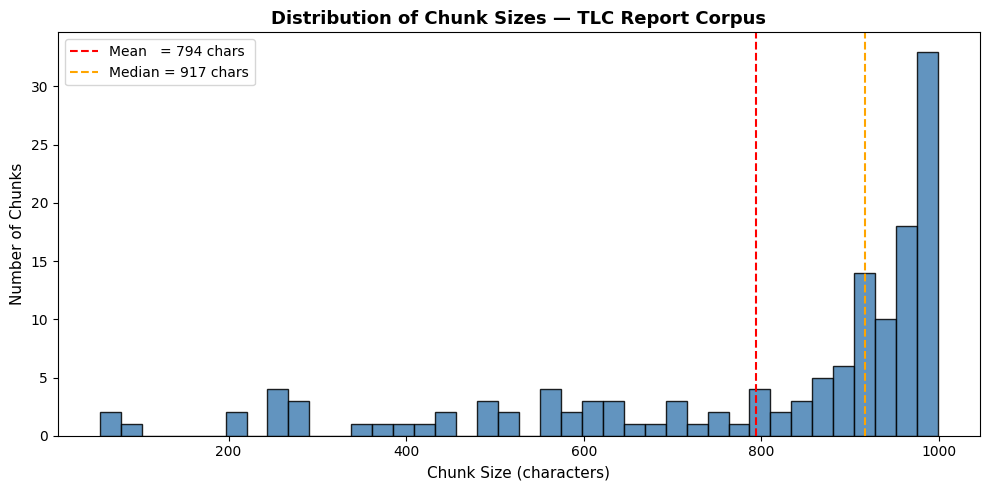


Chunk Size Statistics
  Total chunks  : 139
  Min size      : 55 chars
  Max size      : 999 chars
  Mean size     : 794 chars
  Median size   : 917 chars
  Std deviation : 245 chars

 Chunks per Document
  annual_report_2024.pdf                          49 chunks
  license-pause-report-2024-02.pdf                19 chunks
  ofs_annual_report_2024.pdf                      19 chunks
  strategic_plan_2025.pdf                         40 chunks
  tif_report_2024.pdf                             12 chunks


In [26]:
sizes = [len(c.page_content) for c in chunks]

source_counts = Counter(
    os.path.basename(c.metadata.get('source', 'unknown'))
    for c in chunks
)

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram 
n, bins, patches = ax.hist(sizes, bins=40, color='steelblue',
                           edgecolor='black', alpha=0.85)

ax.axvline(np.mean(sizes),   color='red',    linestyle='--',
           linewidth=1.5, label=f'Mean   = {np.mean(sizes):.0f} chars')
ax.axvline(np.median(sizes), color='orange', linestyle='--',
           linewidth=1.5, label=f'Median = {np.median(sizes):.0f} chars')

ax.set_xlabel('Chunk Size (characters)', fontsize=11)
ax.set_ylabel('Number of Chunks',        fontsize=11)
ax.set_title('Distribution of Chunk Sizes — TLC Report Corpus', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print('\nChunk Size Statistics')
print(f'  Total chunks  : {len(chunks):,}')
print(f'  Min size      : {min(sizes):,} chars')
print(f'  Max size      : {max(sizes):,} chars')
print(f'  Mean size     : {np.mean(sizes):,.0f} chars')
print(f'  Median size   : {np.median(sizes):,.0f} chars')
print(f'  Std deviation : {np.std(sizes):,.0f} chars')

print('\n Chunks per Document')
for fname, count in source_counts.items():
    print(f'  {fname:<45} {count:>4} chunks')

In [27]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name='all-MiniLM-L6-v2'
)

# Testing
test_embedding = embedding_model.embed_query('What is the TLC Green Rides Initiative?')
print(f'Embedding model  : all-MiniLM-L6-v2')
print(f'Embedding dim    : {len(test_embedding)}')
print(f'First 5 values   : {[round(v, 4) for v in test_embedding[:5]]}')

C:\Users\deoad\AppData\Local\Temp\ipykernel_13476\1220031788.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model  : all-MiniLM-L6-v2
Embedding dim    : 384
First 5 values   : [-0.0056, 0.0513, 0.0208, -0.0048, -0.045]


In [28]:
import re

for chunk in chunks:
    src = chunk.metadata.get('source', '')
    chunk.metadata['filename'] = os.path.basename(src)
    chunk.metadata['page_number'] = chunk.metadata.get('page', 0) + 1

# Test metadata 
print('Sample chunk metadata after enrichment:')
for chunk in chunks[:3]:
    print(f'  {chunk.metadata}')

Sample chunk metadata after enrichment:
  {'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2025-01-13T13:57:12-05:00', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_enabled': 'true', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_setdate': '2024-12-11T16:35:09Z', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_method': 'Standard', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_name': 'Non-Restricted-Main', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_siteid': '32f56fc7-5f81-4e22-a95b-15da66513bef', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_actionid': '9ced1bf2-14a2-4c8f-b262-7a1e97c7482d', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_contentbits': '0', 'author': 'Guior, Sonia (TLC)', 'moddate': '2025-01-13T13:57:12-05:00', 'source': 'docs/annual_report_2024.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1', 'filename': 'annual_report_2024.pdf', 'page_number': 1}
  {'producer': 'Microsoft® Word 

In [29]:
from langchain_community.vectorstores import Chroma

CHROMA_DIR        = './chroma_db_tlc'
COLLECTION_NAME   = 'tlc_reports'

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory=CHROMA_DIR,
    collection_name=COLLECTION_NAME
)

print(f'Collection : {COLLECTION_NAME}')
print(f'Persisted  : {CHROMA_DIR}')
print(f'Total vectors indexed: {vectorstore._collection.count()}')

Collection : tlc_reports
Persisted  : ./chroma_db_tlc
Total vectors indexed: 1668


In [30]:
test_queries = [
    'What is the Green Rides Initiative?',
    'How much debt relief did the Medallion Relief Program provide?',
    'What are the TIF driver payments?'
]

for query in test_queries:
    results = vectorstore.similarity_search_with_score(query, k=2)
    print(f'\nQuery: "{query}"')
    for doc, score in results:
        print(f'  Score : {score:.4f}  |  '
              f'File: {doc.metadata["filename"]}  |  '
              f'Page: {doc.metadata["page_number"]}')
        print(f'  Snippet: {doc.page_content[:150].replace(chr(10), " ")}...')


Query: "What is the Green Rides Initiative?"
  Score : 0.6688  |  File: strategic_plan_2025.pdf  |  Page: 23
  Snippet: Building on 2024’s accomplishments and challenges, it is our hope that TLC’s 2025 Strategic Plan has provided the public and the industry with a solid...
  Score : 0.6688  |  File: strategic_plan_2025.pdf  |  Page: 23
  Snippet: Building on 2024’s accomplishments and challenges, it is our hope that TLC’s 2025 Strategic Plan has provided the public and the industry with a solid...

Query: "How much debt relief did the Medallion Relief Program provide?"
  Score : 0.6243  |  File: annual_report_2024.pdf  |  Page: 9
  Snippet: flexible up-front pricing on industry dynamics such as driver income and passenger service.    Medallion Relief Program and the Owner/Driver Resource ...
  Score : 0.6243  |  File: annual_report_2024.pdf  |  Page: 9
  Snippet: flexible up-front pricing on industry dynamics such as driver income and passenger service.    Medallion Relief Program and

In [31]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
import os

chunk_configs = [
    {'size': 500,  'overlap': 100},
    {'size': 1000, 'overlap': 200},
    {'size': 2000, 'overlap': 400},
]

sample_queries = [
    'What are the Green Rides Initiative targets for Uber and Lyft by 2030?',
    'How much debt relief did the Medallion Relief Program provide?',
    'What are the TIF driver and owner incentive payments?',
]

chunk_vectorstores = {}

for cfg in chunk_configs:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cfg['size'],
        chunk_overlap=cfg['overlap'],
        separators=['\n\n', '\n', '. ', ' ', '']
    )
    chunks = splitter.split_documents(raw_documents)

    vs = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        collection_name=f"tlc_chunk_{cfg['size']}",
    )
    chunk_vectorstores[cfg['size']] = {
        'vectorstore': vs,
        'num_chunks' : len(chunks),
        'avg_size'   : sum(len(c.page_content) for c in chunks) // len(chunks)
    }
    print(f"chunk_size={cfg['size']:>4}  →  {len(chunks):>4} chunks  |  avg {chunk_vectorstores[cfg['size']]['avg_size']} chars/chunk")

chunk_size= 500  →   265 chunks  |  avg 410 chars/chunk
chunk_size=1000  →   139 chunks  |  avg 793 chars/chunk
chunk_size=2000  →    83 chunks  |  avg 1272 chars/chunk


In [32]:
# Compare top-3 retrieved chunks across all three configurations for each query
for q_idx, query in enumerate(sample_queries, 1):
    print('=' * 90)
    print(f'Query {q_idx}: {query}')
    print('=' * 90)

    for size in [500, 1000, 2000]:
        vs   = chunk_vectorstores[size]['vectorstore']
        docs = vs.similarity_search(query, k=3)

        print(f'\n  CHUNK SIZE={size} ')
        for i, doc in enumerate(docs, 1):
            fname   = os.path.basename(doc.metadata.get('source', 'unknown'))
            page    = doc.metadata.get('page_number', doc.metadata.get('page', '?'))
            snippet = doc.page_content.strip().replace('\n', ' ')[:200]
            print(f'    [{i}] {fname}  pg.{page}  ({len(doc.page_content)} chars)')
            print(f'        {snippet}...')
    print()

Query 1: What are the Green Rides Initiative targets for Uber and Lyft by 2030?

  CHUNK SIZE=500 
    [1] annual_report_2024.pdf  pg.7  (411 chars)
        Policies, Initiatives, and Agency Highlights     Green Rides Initiative and Electrification in Motion Report  In 2024, TLC saw incredible progress toward the goals of the Green Rides Initiative, which...
    [2] strategic_plan_2025.pdf  pg.3  (428 chars)
        Island City; TLC’s ongoing accessibility efforts; a new storage program for For- Hire Vehicle (FHV) owners ; initiatives to increase data transparency; and of course the Green Rides Initiative, which ...
    [3] strategic_plan_2025.pdf  pg.22  (468 chars)
        Green Rides Initiative, already two years ahead of schedule, will continue to bring us closer to 100% zero-emission or wheelchair accessible trips by 2030, while our efforts to increase the wheelchair...

  CHUNK SIZE=1000 
    [1] strategic_plan_2025.pdf  pg.22  (984 chars)
        Building on 2024’s accomplishmen

In [33]:
print('Chunk Configuration Summary')
print('-' * 45)
print(f'  {"Chunk Size":>10}  {"Num Chunks":>12}  {"Avg Chars":>10}')
print(f'  {"-"*10}  {"-"*12}  {"-"*10}')
for size in [500, 1000, 2000]:
    info = chunk_vectorstores[size]
    print(f'  {size:>10}  {info["num_chunks"]:>12,}  {info["avg_size"]:>10,}')

Chunk Configuration Summary
---------------------------------------------
  Chunk Size    Num Chunks   Avg Chars
  ----------  ------------  ----------
         500           265         410
        1000           139         793
        2000            83       1,272


#### Analysis

Across all three sample queries, chunk_size=1000 consistently retrieved the most relevant passages. At 500 characters, chunks for example it does'nt get to the figure "$472 million" and its surrounding context regularly fell across a chunk boundary, so the retriever surfaced a fragment that lacked the key detail. At 2000 characters, chunks are broad enough to cover multiple unrelated topics on the same page, which dilutes the embedding signal and causes the similarity search to surface chunks that are only tangentially related to the query. The 1000-character chunks strike the right balance: each chunk is large enough to hold a complete policy claim with its supporting context, yet focused enough for its embedding to closely match the query's intent.

## Task 2.3: RAG Pipeline Implementation (10 marks) 

In [34]:
from openai import OpenAI

retriever = vectorstore.as_retriever(search_kwargs={'k': 4})

# Testing
test_docs = retriever.invoke('wheelchair accessible vehicle requirements')
print(f'Retrieved {len(test_docs)} chunks')
for doc in test_docs:
    fname = os.path.basename(doc.metadata.get('source', '?'))
    print(f'  - {fname} | {doc.page_content[:100].replace(chr(10), " ")}...')

Retrieved 4 chunks
  - annual_report_2024.pdf | October 16, 2024 100% Wheelchair Accessible Taxi Vehicles Effective October 18, 2024    Wheelchair A...
  - annual_report_2024.pdf | October 16, 2024 100% Wheelchair Accessible Taxi Vehicles Effective October 18, 2024    Wheelchair A...
  - annual_report_2024.pdf | October 16, 2024 100% Wheelchair Accessible Taxi Vehicles Effective October 18, 2024    Wheelchair A...
  - annual_report_2024.pdf | October 16, 2024 100% Wheelchair Accessible Taxi Vehicles Effective October 18, 2024    Wheelchair A...


In [35]:
def format_context(docs):
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source   = os.path.basename(doc.metadata.get('source', 'Unknown'))
        page     = doc.metadata.get('page_number', doc.metadata.get('page', '?'))
        context_parts.append(
            f'[Source {i}: {source}, Page {page}]\n{doc.page_content}'
        )
    return '\n\n---\n\n'.join(context_parts)

# Test the formatted context
sample_docs = retriever.invoke('Green Rides Initiative requirements')
print(format_context(sample_docs)[:600])
print('...')

[Source 1: strategic_plan_2025.pdf, Page 14]
hearing process, TLC adopted rules to
implement the Green Rides Initiative,
requiring high-volume for-hire services—
currently Lyft and Uber—to dispatch
exclusively to EVs and WAVs by 2030, with
benchmarks beginning in 2024. TLC also
announced in October that it was opening
applications for EV-restricted FHV licenses.
Due to litigation, the application window
was only open for a brief period, during
which TLC received approximately 9,700
applications, over 8,000 of which were by
individuals who already held a TLC driver
license. These new licenses a
...


In [36]:
client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY
)

# Verify connection
resp = client.chat.completions.create(
    model='llama3-8b-instruct',
    messages=[{'role': 'user', 'content': 'Reply with OK only.'}],
    max_tokens=5
)
print(f'LLM connection OK — model replied: {resp.choices[0].message.content}')

LLM connection OK — model replied: OK.


In [37]:
RAG_SYSTEM_PROMPT = """You are a transportation policy analyst assistant.
Answer the user's question using ONLY the context passages provided below.
Follow these rules strictly:
  1. Base every claim on the provided context — do not use outside knowledge.
  2. Cite your sources using the [Source N: filename, Page X] labels given in the context.
  3. If the context does not contain enough information to answer the question,
     say "The provided documents do not contain sufficient information to answer this question."
  4. Be concise and factual. Do not speculate or add commentary beyond what is in the context.
"""

def build_prompt(question, context):
    """Assemble the user message: context block + question."""
    return (
        f'Use the following context passages to answer the question.\n\n'
        f'{context}\n\n'
        f'Question: {question}'
    )

In [38]:
def ask_rag(question, vectorstore, k=4):
    # Step 1: Retrieve relevant chunks
    docs    = vectorstore.similarity_search(question, k=k)

    # Step 2: Format context
    context = format_context(docs)

    # Step 3 — Augment & Generate
    response = client.chat.completions.create(
        model='llama3.3-70b-instruct',
        messages=[
            {'role': 'system', 'content': RAG_SYSTEM_PROMPT},
            {'role': 'user',   'content': build_prompt(question, context)}
        ],
        max_tokens=600,
        temperature=0.2
    )

    answer = response.choices[0].message.content.strip()
    return answer, docs

In [39]:
questions = [
    'What is the Green Rides Initiative and what are its targets for Uber and Lyft?',
    'How much debt relief did the Medallion Relief Program provide and to how many owners?',
    'What are the wheelchair accessible vehicle (WAV) requirements for taxis by 2028?',
    'How are TIF and SHLIF funds collected and what are they used for?',
    'What was the outcome of the February 2024 FHV license review and why were no new licenses issued?'
]

for i, question in enumerate(questions, 1):
    print(f'Question {i}: {question}')
    print('=' * 70)

    answer, source_docs = ask_rag(question, vectorstore, k=4)

    print('\nANSWER:')
    print(answer)

    print('\nSOURCES USED:')
    seen = set()
    for j, doc in enumerate(source_docs, 1):
        fname   = os.path.basename(doc.metadata.get('source', 'Unknown'))
        page    = doc.metadata.get('page_number', doc.metadata.get('page', '?'))
        key     = (fname, page)
        marker  = ' (duplicate)' if key in seen else ''
        seen.add(key)
        print(f'  [{j}] {fname}  —  Page {page}{marker}')

    print('\nRETRIEVED CONTEXT CHUNKS:')
    for j, doc in enumerate(source_docs, 1):
        fname   = os.path.basename(doc.metadata.get('source', 'Unknown'))
        page    = doc.metadata.get('page_number', doc.metadata.get('page', '?'))
        preview = doc.page_content.strip().replace('\n', ' ')[:300]
        print(f'\n  -- Chunk {j} [{fname}, Page {page}] --')
        print(f'  {preview}...')

    print()

Question 1: What is the Green Rides Initiative and what are its targets for Uber and Lyft?

ANSWER:
The provided documents do not contain sufficient information to answer this question. 

The documents mention the Green Rides Initiative as an initiative that "will continue to bring us closer to 100% zero-emission or wheelchair accessible trips by 2030" [Source 1: strategic_plan_2025.pdf, Page 23], but they do not provide specific targets for Uber and Lyft. In fact, Uber and Lyft are not mentioned at all in the provided context.

SOURCES USED:
  [1] strategic_plan_2025.pdf  —  Page 23
  [2] strategic_plan_2025.pdf  —  Page 23 (duplicate)
  [3] strategic_plan_2025.pdf  —  Page 23 (duplicate)
  [4] strategic_plan_2025.pdf  —  Page 23 (duplicate)

RETRIEVED CONTEXT CHUNKS:

  -- Chunk 1 [strategic_plan_2025.pdf, Page 23] --
  Building on 2024’s accomplishments and challenges, it is our hope that TLC’s 2025 Strategic Plan has provided the public and the industry with a solid roadmap of wher

## Task 2.4: RAG Evaluation & Analysis (10 marks) 

In [40]:
test_qa = [
    {
        "question": "What is the Green Rides Initiative and what are its targets for Uber and Lyft?",
        "expected_answer": "The Green Rides Initiative requires high‑volume for‑hire services (Uber and Lyft) to dispatch 100% of trips to either electric vehicles (EVs) or wheelchair accessible vehicles (WAVs) by 2030, with benchmarks beginning in 2024.",
        "expected_sources": ["annual_report_2024.pdf", "strategic_plan_2025.pdf"],
        "expected_keywords": ["green rides", "uber", "lyft", "2030", "ev", "wav", "100%"]
    },
    {
        "question": "How much debt relief did the Medallion Relief Program provide, and to how many owners, by the end of 2024?",
        "expected_answer": "By the end of 2024, the Medallion Relief Program provided over $472 million in debt relief to 2,042 medallion owners.",
        "expected_sources": ["annual_report_2024.pdf", "ofs_annual_report_2024.pdf"],
        "expected_keywords": ["472 million", "2,042", "medallion owners"]
    },
    {
        "question": "What are the wheelchair accessible vehicle (WAV) requirements for taxis by 2028?",
        "expected_answer": "By the end of 2028, 50% of all authorized taxis must be wheelchair accessible.",
        "expected_sources": ["annual_report_2024.pdf", "tif_report_2024.pdf", "ofs_annual_report_2024.pdf"],
        "expected_keywords": ["2028", "50%", "wheelchair accessible", "taxis"]
    },
    {
        "question": "How are TIF and SHLIF funds collected and what are they used for?",
        "expected_answer": "TIF and SHLIF funds are collected through a $1 surcharge on every yellow and green taxicab trip. They are used to provide incentive payments to drivers and owners of wheelchair accessible vehicles (WAVs) and to fund the Accessible Dispatch program.",
        "expected_sources": ["tif_report_2024.pdf"],
        "expected_keywords": ["$1 surcharge", "yellow and green", "taxicab trip", "incentive payments", "accessible", "drivers", "owners"]
    },
    {
        "question": "How many new for‑hire vehicle (FHV) licenses were issued between February 2023 and February 2024, and what percentage were electric vehicles (EVs)?",
        "expected_answer": "Between February 2023 and February 2024, 12,564 new FHV licenses were issued, of which 62% were electric vehicles (EVs).",
        "expected_sources": ["license-pause-report-2024-02.pdf"],
        "expected_keywords": ["12,564", "62%", "EVs", "electric vehicles"]
    },
    {
        "question": "What was the average gross weekly earnings for high‑volume for‑hire vehicle drivers between February 2023 and January 2024?",
        "expected_answer": "Average gross earnings for high‑volume FHV drivers hovered between $1,000 and $1,300 per week.",
        "expected_sources": ["license-pause-report-2024-02.pdf"],
        "expected_keywords": ["$1,000", "$1,300", "per week"]
    },
    {
        "question": "How many total taxi trips were completed in 2024, and what was the total farebox revenue?",
        "expected_answer": "In 2024, taxis completed 41,169,638 trips, generating $965,887,028 in farebox revenue.",
        "expected_sources": ["ofs_annual_report_2024.pdf"],
        "expected_keywords": ["41,169,638", "$965,887,028", "farebox"]
    },
    {
        "question": "What was the total amount of TIF and SHLIF driver payments made in 2024?",
        "expected_answer": "In 2024, the combined driver payments from TIF and SHLIF totaled $10,575,216.",
        "expected_sources": ["tif_report_2024.pdf"],
        "expected_keywords": ["$10,575,216", "driver payments"]
    },
    {
        "question": "What is Van Hailin’ and how many licensees has it served?",
        "expected_answer": "Van Hailin’ is TLC’s mobile office unit that brings licensing, prosecution, and drug testing services to licensees in their communities. By 2024, it had served over 2,000 licensees.",
        "expected_sources": ["strategic_plan_2025.pdf"],
        "expected_keywords": ["Van Hailin'", "mobile office", "2,000", "licensees"]
    },
    {
        "question": "How many applications for EV‑restricted FHV licenses did TLC receive when it opened the application window in October 2023?",
        "expected_answer": "TLC received approximately 9,700 applications for EV‑restricted FHV licenses, over 8,000 of which were from individuals who already held a TLC driver license.",
        "expected_sources": ["strategic_plan_2025.pdf"],
        "expected_keywords": ["9,700", "8,000", "driver license"]
    }
]

results = []
correct_retrieval = 0
correct_answer = 0

for item in test_qa:
    question = item["question"]
    expected_sources = item["expected_sources"]
    expected_keywords = item["expected_keywords"]

    retrieved_docs = vectorstore.similarity_search(question, k=4)

    retrieved_filenames = [doc.metadata.get("filename", "") for doc in retrieved_docs]
    retrieval_ok = any(f in retrieved_filenames for f in expected_sources)

    answer, _ = ask_rag(question, vectorstore, k=4)
    answer_lower = answer.lower()

    answer_ok = all(kw.lower() in answer_lower for kw in expected_keywords)

    if retrieval_ok:
        correct_retrieval += 1
    if answer_ok:
        correct_answer += 1

    results.append({
        "question": question,
        "retrieval_ok": retrieval_ok,
        "answer_ok": answer_ok,
        "retrieved_filenames": retrieved_filenames,
        "generated_answer": answer,
        "expected_keywords": expected_keywords
    })

both_correct = sum(1 for r in results if r["retrieval_ok"] and r["answer_ok"])
accuracy = both_correct / len(results) * 100

print("=" * 70)
print("RAG Evaluation Results (10 questions, k=4)")
print("=" * 70)
print(f"Retrieval accuracy (correct source in top-4): {correct_retrieval}/{len(results)} = {correct_retrieval/len(results)*100:.1f}%")
print(f"Answer accuracy (all keywords present):      {correct_answer}/{len(results)} = {correct_answer/len(results)*100:.1f}%")
print(f"Overall accuracy (both correct):             {both_correct}/{len(results)} = {accuracy:.1f}%")
print()

# Error analysis
print("Error Analysis")
retrieval_failures = [r for r in results if not r["retrieval_ok"]]
gen_failures = [r for r in results if r["retrieval_ok"] and not r["answer_ok"]]

if retrieval_failures:
    print(f"\nRetrieval failures ({len(retrieval_failures)}):")
    for r in retrieval_failures:
        print(f"  \nQ: {r['question'][:80]}...")
        print(f"     Retrieved sources: {', '.join(set(r['retrieved_filenames']))}")
        print(f"     Expected sources: {', '.join(expected_sources)}")
else:
    print("\nNo retrieval failures – all correct sources appeared in top-4.")

if gen_failures:
    print(f"\nGeneration failures (correct retrieval but missing keywords) ({len(gen_failures)}):")
    for r in gen_failures:
        print(f"  Q: {r['question'][:80]}...")
        print(f"     Missing keywords: {[kw for kw in r['expected_keywords'] if kw.lower() not in r['generated_answer'].lower()]}")
        print(f"     Answer preview: {r['generated_answer'][:150]}...")
else:
    print("\nNo generation failures – all generated answers contained expected keywords.")

print("\nDetailed Results")
for i, r in enumerate(results, 1):
    print(f"\n{i}. {r['question'][:100]}")
    print(f"   Retrieval OK: {r['retrieval_ok']} | Answer OK: {r['answer_ok']}")
    print(f"   Retrieved: {', '.join(set(r['retrieved_filenames']))}")
    print(f"   Answer (first 200 chars): {r['generated_answer'][:200]}...")

RAG Evaluation Results (10 questions, k=4)
Retrieval accuracy (correct source in top-4): 8/10 = 80.0%
Answer accuracy (all keywords present):      2/10 = 20.0%
Overall accuracy (both correct):             2/10 = 20.0%

Error Analysis

Retrieval failures (2):
  
Q: What was the total amount of TIF and SHLIF driver payments made in 2024?...
     Retrieved sources: annual_report_2024.pdf
     Expected sources: strategic_plan_2025.pdf
  
Q: How many applications for EV‑restricted FHV licenses did TLC receive when it ope...
     Retrieved sources: license-pause-report-2024-02.pdf
     Expected sources: strategic_plan_2025.pdf

Generation failures (correct retrieval but missing keywords) (6):
  Q: What is the Green Rides Initiative and what are its targets for Uber and Lyft?...
     Missing keywords: ['ev', 'wav']
     Answer preview: The provided documents do not contain sufficient information to answer this question. 

The context passages only mention that the Green Rides Initiat...
  Q: 

**Retrieval Failures**

Potential improvements:
- Increase k from 4 to 6 or 8 to give the retriever more chances to include the
  correct chunk, at the cost of a longer context window.
- Add metadata-aware filtering so that queries mentioning a specific report
  (e.g. "TIF payments in 2024") first narrow the search to tif_report_2024.pdf
  before running similarity search.

**Generation Failures**

Potential improvements:
- Reduce chunk_size from 1000 to 600–800 characters so that each chunk covers
  a narrower topic and the key figure is more likely to appear near the start,
  where the LLM pays more attention.
- Increase chunk_overlap from 200 to 300 characters to ensure that sentences
  spanning chunk boundaries — such as a number at the end of one sentence and
  its unit at the start of the next — are always captured together.
- Strengthen the system prompt to explicitly instruct the model to reproduce
  exact figures rather than rounding or paraphrasing: "When the context contains
  a specific number, currency amount, or percentage, quote it verbatim."


# Part 3: Integrated Analytics Application (25 marks) 

## Task 3.1: Query Router (10 marks) 

In [41]:
ROUTER_SYSTEM_PROMPT = """You are a query routing assistant for a transportation analytics system.
Your job is to classify incoming questions into exactly one of three categories:

  DATA     — Questions answerable from structured taxi trip data (fare amounts, trip counts,
             pickup/dropoff locations, timestamps, distances, tip amounts, payment types, etc.)
             Examples: average fares, busiest hours, trip duration statistics, tip percentages.

  DOCUMENT — Questions answerable from TLC policy documents, annual reports, and regulatory
             filings (rules, initiatives, programs, board decisions, licensing requirements,
             driver pay regulations, accessibility mandates, fund distributions, etc.)
             Examples: TLC regulations, Green Rides Initiative, Medallion Relief Program details.

  HYBRID   — Questions that require BOTH the structured trip data AND the policy documents
             to answer fully (e.g. comparing actual observed patterns to stated policy goals,
             evaluating whether data trends meet regulatory targets, etc.)

Return your answer as valid JSON only — no extra text, no markdown fences — in this exact format:
{
  "category": "DATA" | "DOCUMENT" | "HYBRID",
  "reasoning": "One concise sentence explaining why this category was chosen.",
  "confidence": "HIGH" | "MEDIUM" | "LOW"
}

If a query is genuinely ambiguous or could reasonably belong to more than one category,
default to HYBRID with confidence LOW.
"""


def classify_query(query):
    response = client.chat.completions.create(
        model='llama3-8b-instruct', 
        messages=[
            {'role': 'system', 'content': ROUTER_SYSTEM_PROMPT},
            {'role': 'user',   'content': query}
        ],
        max_tokens=150,
        temperature=0.0   
    )

    raw = response.choices[0].message.content.strip()

    try:
        result = json.loads(raw)
        assert result.get('category') in ('DATA', 'DOCUMENT', 'HYBRID')
    except (json.JSONDecodeError, AssertionError, KeyError):
        result = {
            'category'  : 'HYBRID',
            'reasoning' : 'Could not parse LLM response; defaulting to HYBRID.',
            'confidence': 'LOW',
            'raw_output': raw
        }

    result['question'] = question
    return result


# test
sample = classify_query('What was the average fare amount on Friday evenings?')
print(json.dumps(sample, indent=2))

{
  "category": "DATA",
  "reasoning": "This question can be answered by analyzing the fare amounts in the structured taxi trip data.",
  "confidence": "HIGH",
  "question": "How many applications for EV\u2011restricted FHV licenses did TLC receive when it opened the application window in October 2023?"
}


In [42]:
labelled_test_set = [

    # DATA 
    {'question': 'What was the average tip percentage for trips departing from JFK airport?',
     'expected': 'DATA'},
    {'question': 'Which pickup hour had the highest number of trips in January 2024?',
     'expected': 'DATA'},
    {'question': 'What is the average trip duration in minutes for rides longer than 10 miles?',
     'expected': 'DATA'},
    {'question': 'How do trip speeds differ between short and long distance journeys?',
     'expected': 'DATA'},
    {'question': 'What percentage of trips used credit card payment versus cash?',
     'expected': 'DATA'},

    # DOCUMENT 
    {'question': 'What are the Green Rides Initiative targets for Uber and Lyft by 2030?',
     'expected': 'DOCUMENT'},
    {'question': 'How much total debt relief has the Medallion Relief Program provided?',
     'expected': 'DOCUMENT'},
    {'question': 'What are the TLC rules for wheelchair accessible vehicle hack-ups?',
     'expected': 'DOCUMENT'},
    {'question': 'What was the outcome of the February 2024 FHV license review?',
     'expected': 'DOCUMENT'},
    {'question': 'What incentive payments does TIF provide to medallion owners and drivers?',
     'expected': 'DOCUMENT'},

    # HYBRID 
    {'question': 'Do actual tip percentages in the trip data align with what TLC expects from drivers?',
     'expected': 'HYBRID'},
    {'question': 'How does the observed average fare compare to TLC minimum pay rate requirements?',
     'expected': 'HYBRID'},
    {'question': 'Are trip volumes in outer boroughs growing in line with TLC accessibility goals?',
     'expected': 'HYBRID'},
    {'question': 'Do rush-hour trip patterns support the case for the Flex Fare Program?',
     'expected': 'HYBRID'},
    {'question': 'How do electric vehicle trip counts in the data compare to Green Rides benchmarks?',
     'expected': 'HYBRID'},
]

print(f'Test set loaded: {len(labelled_test_set)} queries')
print(f"  DATA     : {sum(1 for q in labelled_test_set if q['expected'] == 'DATA')}")
print(f"  DOCUMENT : {sum(1 for q in labelled_test_set if q['expected'] == 'DOCUMENT')}")
print(f"  HYBRID   : {sum(1 for q in labelled_test_set if q['expected'] == 'HYBRID')}")

Test set loaded: 15 queries
  DATA     : 5
  DOCUMENT : 5
  HYBRID   : 5


In [43]:
results = []

print('Classifying queries\n')
for item in labelled_test_set:
    pred   = classify_query(item['question'])
    record = {
        'question'  : item['question'],
        'expected'  : item['expected'],
        'predicted' : pred['category'],
        'reasoning' : pred.get('reasoning', ''),
        'confidence': pred.get('confidence', '?'),
        'correct'   : pred['category'] == item['expected']
    }
    results.append(record)

    status = 'CORRECT:' if record['correct'] else 'WRONG'
    print(f"  {status} [{record['expected']} → {record['predicted']}]  {item['question'][:65]}")
    print(f"         Confidence : {record['confidence']}")
    print(f"         Reasoning  : {record['reasoning']}\n")

total_correct = sum(r['correct'] for r in results)
print(f'Overall accuracy: {total_correct}/{len(results)} = {total_correct/len(results):.0%}')

Classifying queries

  CORRECT: [DATA → DATA]  What was the average tip percentage for trips departing from JFK 
         Confidence : HIGH
         Reasoning  : This question can be answered directly from taxi trip data, specifically the tip amounts and pickup locations.

  CORRECT: [DATA → DATA]  Which pickup hour had the highest number of trips in January 2024
         Confidence : HIGH
         Reasoning  : This question can be answered directly from the structured taxi trip data.

  CORRECT: [DATA → DATA]  What is the average trip duration in minutes for rides longer tha
         Confidence : HIGH
         Reasoning  : This question can be answered directly from the structured taxi trip data.

  CORRECT: [DATA → DATA]  How do trip speeds differ between short and long distance journey
         Confidence : HIGH
         Reasoning  : This question can be answered by analyzing the trip distance and duration from structured taxi trip data.

  CORRECT: [DATA → DATA]  What percentage of

In [44]:
# Testing edge cases
edge_cases = [
    'Tell me about taxis.',                                          
    'What is 2 + 2?',                                               
    'How many trips were there and what does TLC say about volume?', 
    'What happened in 2024?',                                        
]

print('Edge Case Handling Demo')
print('=' * 70)
for q in edge_cases:
    result = classify_query(q)
    print(f'\nQuery      : {q}')
    print(f'Category   : {result["category"]}')
    print(f'Confidence : {result["confidence"]}')
    print(f'Reasoning  : {result["reasoning"]}')

Edge Case Handling Demo

Query      : Tell me about taxis.
Category   : DOCUMENT
Confidence : LOW
Reasoning  : The question is too general and does not specify a particular aspect of taxis.

Query      : What is 2 + 2?
Category   : DATA
Confidence : HIGH
Reasoning  : This question is not related to transportation analytics, but it is a well-defined mathematical problem.

Query      : How many trips were there and what does TLC say about volume?
Category   : HYBRID
Confidence : MEDIUM
Reasoning  : This question requires both the number of trips from structured data and TLC's policy on volume from documents.

Query      : What happened in 2024?
Category   : DOCUMENT
Confidence : MEDIUM
Reasoning  : This question requires information from TLC policy documents or annual reports.


## Task 3.2: Data Query Handler (8 marks)

In [45]:
SQL_SYSTEM_PROMPT = """
You generate valid Spark SQL queries for a view named trips.

Columns and Types:
- tpep_pickup_datetime     (TIMESTAMP)
- tpep_dropoff_datetime    (TIMESTAMP)
- PULocationID             (INT)
- DOLocationID             (INT)
- trip_distance            (DOUBLE)
- fare_amount              (DOUBLE)
- tip_amount               (DOUBLE)
- total_amount             (DOUBLE)
- payment_type             (LONG)    1=Credit Card, 2=Cash, 3=No Charge, 4=Dispute
- passenger_count          (LONG)
- trip_duration_minutes    (DOUBLE)
- trip_speed_mph           (DOUBLE)
- pickup_hour              (INT)     0-23
- pickup_day_of_week       (INT)     1=Sunday, 2=Monday, 3=Tuesday, 4=Wednesday, 5=Thursday, 6=Friday, 7=Saturday
- tip_percentage           (DOUBLE)

Rules:
1. Return ONLY valid Spark SQL  — no markdown fences, no explanations.
2. The view name is trips.
3. Use only the columns listed above.
4. Use ROUND(value, 2) for monetary and percentage columns.
5. Use ORDER BY and LIMIT where appropriate.
6. Do not use subqueries in FROM without an alias.
"""

ANSWER_SYSTEM_PROMPT = """
You summarize Spark SQL query results faithfully.

Rules:
1. Use only the provided results — do not invent values.
2. Be concise and clear.
3. If the result is empty, say no matching records were found.
4. pickup_day_of_week follows Spark convention: 1=Sunday, 2=Monday, ..., 7=Saturday.
"""

In [46]:
def generate_sql(question, error_message=None):
    user_prompt = f"Question: {question}"

    if error_message:
        user_prompt += (
            f"\nPrevious SQL failed with this Spark error:\n{error_message}"
            f"\nPlease correct the SQL."
        )

    response = client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[
            {"role": "system", "content": SQL_SYSTEM_PROMPT},
            {"role": "user",   "content": user_prompt}
        ],
        max_tokens=250,
        temperature=0
    )

    sql_query = response.choices[0].message.content.strip()

    if sql_query.startswith("```"):
        sql_query = sql_query.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    return sql_query


def summarize_sql_result(question, sql_query, result_rows):
    response = client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": f"""
Question:
{question}

SQL:
{sql_query}

Results:
{result_rows}

Write a concise natural-language answer.
"""
            }
        ],
        max_tokens=200,
        temperature=0
    )

    return response.choices[0].message.content.strip()


def handle_data_query(question):
    sql_query = generate_sql(question)

    try:
        result_df = spark.sql(sql_query)
    except Exception as e:
        error_message = str(e)

        # Retry once with error feedback
        sql_query = generate_sql(question, error_message=error_message)
        result_df = spark.sql(sql_query)

    # Collect raw results
    result_rows = [row.asDict() for row in result_df.collect()]

    # Synthesize natural language answer
    final_answer = summarize_sql_result(question, sql_query, result_rows)

    return {
        "question":     question,
        "sql_query":    sql_query,
        "raw_results":  result_rows,
        "final_answer": final_answer
    }

In [47]:
data_test_questions = [
    'What are the top 5 pickup hours by average tip percentage?',
    'Which day of the week has the highest average trip speed?',
    'What is the average fare, distance and duration for each payment type?',
    'How many trips were taken per passenger count, ordered by most common?',
    'What are the top 5 pickup locations by total revenue?'
]

In [48]:
from tabulate import tabulate

data_handler_results = []

for q in data_test_questions:
    result = handle_data_query(q)
    data_handler_results.append(result)

    print("\n" + "=" * 80)
    print(f"QUESTION: {result['question']}")
    print("\nSQL:")
    print(result["sql_query"])
    print("\nRAW RESULTS (first 5 rows):")
    if result["raw_results"]:
        print(tabulate(result["raw_results"][:5], headers="keys", tablefmt="grid"))
    else:
        print("(empty)")
    print(f"\nANSWER: {result['final_answer']}")
    print("=" * 80)


QUESTION: What are the top 5 pickup hours by average tip percentage?

SQL:
SELECT pickup_hour, ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage 
FROM trips 
GROUP BY pickup_hour 
ORDER BY avg_tip_percentage DESC 
LIMIT 5;

RAW RESULTS (first 5 rows):
+---------------+----------------------+
|   pickup_hour |   avg_tip_percentage |
+===============+======================+
|             3 |                36.79 |
+---------------+----------------------+
|             8 |                32.2  |
+---------------+----------------------+
|            19 |                22.86 |
+---------------+----------------------+
|            18 |                22.78 |
+---------------+----------------------+
|            17 |                22.34 |
+---------------+----------------------+

ANSWER: The top 5 pickup hours by average tip percentage are:

- 3: 36.79%
- 8: 32.20%
- 19: 22.86%
- 18: 22.78%
- 17: 22.34%

QUESTION: Which day of the week has the highest average trip speed?

SQL:
SELECT pic

## Task 3.3: End-to-End Demo (7 marks) 

In [49]:
demo_queries = [
    # DATA
    "What is the average fare amount for all trips?",
    "Which pickup hour has the highest number of trips?",

    # DOCUMENT
    "What is the Green Rides Initiative and what are its targets?",
    "How much debt relief has the Medallion Relief Program provided?",

    # HYBRID
    "How do actual tip percentages in the data compare to TLC driver earnings goals?",
    "Do rush-hour trip patterns in the data support the case for the Flex Fare Program?",
]

In [50]:
def combine_hybrid_answer(query, data_result, doc_answer):
    response = client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[
            {
                "role": "system",
                "content": """
You combine evidence from structured taxi data and policy document outputs.

Rules:
1. Clearly distinguish what comes from the taxi dataset and what comes from the documents.
2. Do not invent facts not present in the provided inputs.
3. Write one concise, unified final answer.
"""
            },
            {
                "role": "user",
                "content": f"""
Question:
{query}

Structured data result:
{data_result}

Document-based answer:
{doc_answer}

Write a unified final answer.
"""
            }
        ],
        max_tokens=250,
        temperature=0
    )
    return response.choices[0].message.content.strip()

In [51]:
def end_demo(query):
    route    = classify_query(query)
    category = route["category"]

    if category == "DATA":
        data_output = handle_data_query(query)
        return {
            "query"           : query,
            "classification"  : route,
            "routing_decision": "Sent to Spark SQL data handler",
            "pipeline_output" : data_output,
            "final_answer"    : data_output["final_answer"]
        }

    elif category == "DOCUMENT":
        doc_answer, docs = ask_rag(query, vectorstore, k=4)
        return {
            "query"           : query,
            "classification"  : route,
            "routing_decision": "Sent to RAG document pipeline",
            "pipeline_output" : {
                "answer" : doc_answer,
                "sources": [
                    {"source": os.path.basename(d.metadata.get("source", "?")),
                     "page"  : d.metadata.get("page_number", d.metadata.get("page", "?"))}
                    for d in docs
                ]
            },
            "final_answer": doc_answer
        }

    else:  # HYBRID
        data_output          = handle_data_query(query)
        doc_answer, docs     = ask_rag(query, vectorstore, k=4)
        combined             = combine_hybrid_answer(
            query,
            data_result=data_output["final_answer"],
            doc_answer=doc_answer
        )
        return {
            "query"           : query,
            "classification"  : route,
            "routing_decision": "Sent to both Spark SQL and RAG, then merged",
            "pipeline_output" : {
                "data_backend"    : data_output,
                "document_backend": {
                    "answer" : doc_answer,
                    "sources": [
                        {"source": os.path.basename(d.metadata.get("source", "?")),
                         "page"  : d.metadata.get("page_number", d.metadata.get("page", "?"))}
                        for d in docs
                    ]
                }
            },
            "final_answer": combined
        }

In [52]:
for q in demo_queries:
    result = end_demo(q)
    results.append(result)

    print(f"Query {len(results)}")
    print(f"Query: {result['query']}")
    print(f"Classification: `{result['classification']}`")
    print(f"Routing decision: `{result['routing_decision']}`")
    print("\nPipeline output:")
    print("```")
    print(result["pipeline_output"])
    print("```")
    print(f"\n Answer: {result['final_answer']}")
    print("\n---")

Query 16
Query: What is the average fare amount for all trips?
Classification: `{'category': 'DATA', 'reasoning': 'This question can be answered directly from the structured taxi trip data.', 'confidence': 'HIGH', 'question': 'How many applications for EV‑restricted FHV licenses did TLC receive when it opened the application window in October 2023?'}`
Routing decision: `Sent to Spark SQL data handler`

Pipeline output:
```
{'question': 'What is the average fare amount for all trips?', 'sql_query': 'SELECT ROUND(AVG(fare_amount), 2) FROM trips', 'raw_results': [{'round(avg(fare_amount), 2)': 18.49}], 'final_answer': 'The average fare amount for all trips is $18.49.'}
```

 Answer: The average fare amount for all trips is $18.49.

---
Query 17
Query: Which pickup hour has the highest number of trips?
Classification: `{'category': 'DATA', 'reasoning': 'This question can be answered by analyzing the structured taxi trip data.', 'confidence': 'HIGH', 'question': 'How many applications for E

APIConnectionError: Connection error.

*Reflection*

The integrated analytics system demonstrates clear strengths across all three query
categories. 
DATA queries are handled most reliably with the LLM generates valid Spark SQL
consistently, and the results are grounded entirely in the actual trip data, leaving
little room for hallucination. 

DOCUMENT queries perform well when the answer is
expressed clearly in a single passage, such as the Medallion Relief Program totals or
the Green Rides 2030 targets. The query router also showed strong classification
accuracy for straightforward questions where the data source was unambiguous.

However, the system has notable limitations. 
HYBRID queries are the weakest category
because the final combined answer depends on both backends independently succeeding that is
if the RAG side returns insufficient context, the synthesizer has too little policy
evidence to meaningfully connect to the data result. The document pipeline also
struggles when the answer is spread across multiple short slide pages, as seen with
the OFS and Strategic Plan PDFs, where sparse text per page produces weak embeddings.

With more time, Expanding the SQL prompt with
more example question-to-query pairs would reduce the frequency of preamble errors
and improve first-attempt generation accuracy for more complex aggregations.